### Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

### Read real/fake news dataset

In [2]:
data = pd.read_csv("./dataset/data.csv")
display(data.head(10))
print(data.shape)
print(data.isna().sum())

,label,title,text,subject,date
0,1,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,1,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,1,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
5,1,"White House, Congress prepare for talks on spe...","WEST PALM BEACH, Fla./WASHINGTON (Reuters) - T...",politicsNews,"December 29, 2017"
6,1,"Trump says Russia probe will be fair, but time...","WEST PALM BEACH, Fla (Reuters) - President Don...",politicsNews,"December 29, 2017"
7,1,Factbox: Trump on Twitter (Dec 29) - Approval ...,The following statements were posted to the ve...,politicsNews,"December 29, 2017"
8,1,Trump on Twitter (Dec 28) - Global Warming,The following statements were posted to the ve...,politicsNews,"December 29, 2017"
9,1,Alabama official to certify Senator-elect Jone...,WASHINGTON (Reuters) - Alabama Secretary of St...,politicsNews,"December 28, 2017"


(39942, 5)
label      0
title      0
text       0
subject    0
date       0
dtype: int64


### Drop duplicate news by title

In [3]:
data.drop_duplicates(subset=['title'], inplace=True)
print(data.shape)

(36083, 5)


### EDA — what does the data look like?
Three quick checks before modeling: class balance (is accuracy a fair metric?),
the `subject` column (spoiler: pure label leakage, so it is **not** used as a feature),
and article length by class.

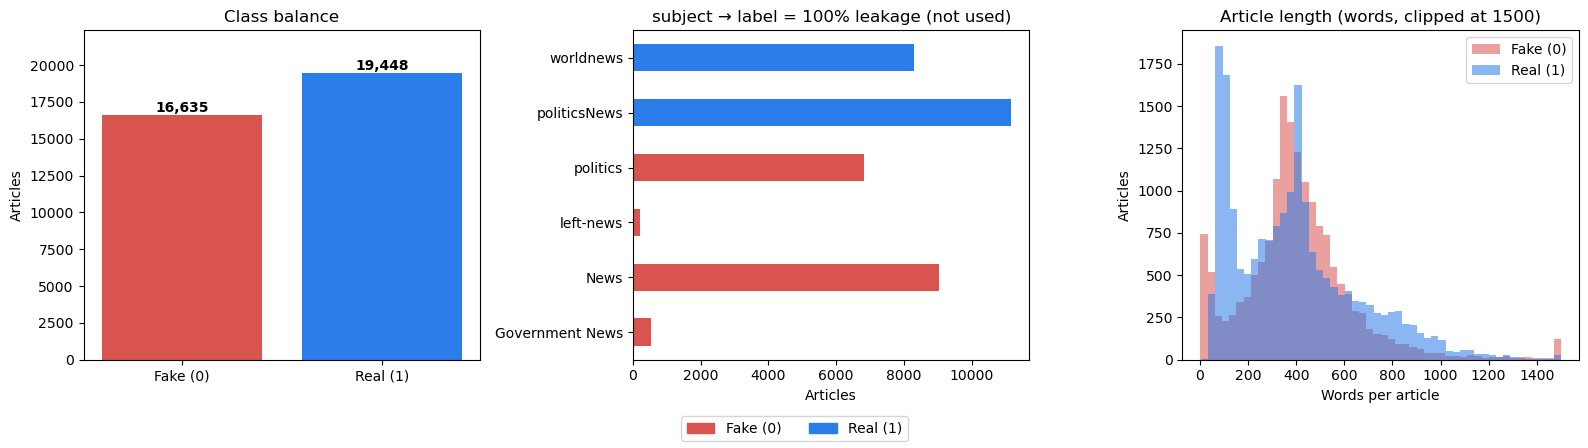

In [4]:
COLORS = {0: '#d9534f', 1: '#2b7de9'}   # fake = red, real = green
LABELS = {0: 'Fake (0)', 1: 'Real (1)'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Class balance
ax = axes[0]
counts = data['label'].value_counts().sort_index()
bars = ax.bar([LABELS[i] for i in counts.index], counts.values,
              color=[COLORS[i] for i in counts.index])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 200, f'{v:,}', ha='center', fontweight='bold')
ax.set_title('Class balance'); ax.set_ylabel('Articles'); ax.set_ylim(0, counts.max()*1.15)

# 2. subject vs label -> 100% leakage, dropped as feature
ax = axes[1]
pd.crosstab(data['subject'], data['label']).plot(
    kind='barh', stacked=True, ax=ax, color=[COLORS[0], COLORS[1]], legend=False)
ax.set_title('subject → label = 100% leakage (not used)'); ax.set_xlabel('Articles'); ax.set_ylabel('')

# 3. Article length by class
ax = axes[2]
n_words = (data['title'].fillna('') + ' ' + data['text'].fillna('')).str.split().str.len()
for lbl in [0, 1]:
    ax.hist(n_words[data['label'] == lbl].clip(upper=1500), bins=50, alpha=0.55,
            color=COLORS[lbl], label=LABELS[lbl])
ax.set_title('Article length (words, clipped at 1500)')
ax.set_xlabel('Words per article'); ax.set_ylabel('Articles'); ax.legend()

handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS[i]) for i in [0, 1]]
fig.legend(handles, [LABELS[0], LABELS[1]], loc='lower center', ncol=2)
plt.tight_layout(rect=[0, 0.06, 1, 1]); plt.show()

### Split dataset into train and test datasets 80%/20%

In [5]:
from sklearn.model_selection import train_test_split

data_train, data_val = train_test_split(
    data,
    test_size=0.2,
    stratify=data['label'],   # preserve fake/real ratio in both sets
    random_state=42
)

In [6]:
print(f"data_train: {data_train.shape}")
print(f"data_val: {data_val.shape}")

data_train: (28866, 5)
data_val: (7217, 5)


### Execute data preprocessing adding three columns ['content', 'tokens', 'preprocessed_text']
- **content**: news title + news text
- **tokens**: content tokenized
- **preprocessed_text**: text cleaned from stopwords, punctuations, spaces and lemmatized

In [7]:
from preprocessing import get_preprocessing_attributes

data_train_preprocessed = get_preprocessing_attributes(data_train)
data_val_preprocessed = get_preprocessing_attributes(data_val)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\agcor\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\agcor\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\agcor\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\agcor\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### Bag of words + Logistic regression algortihm

In [8]:
# BoW + Logistic regression
count_vectorizer = CountVectorizer()
X_train_count = count_vectorizer.fit_transform(data_train_preprocessed['preprocessed_text'])
X_val_count = count_vectorizer.transform(data_val_preprocessed['preprocessed_text'])

lr_bow_classifier = LogisticRegression()
lr_bow_classifier.fit(X_train_count, data_train_preprocessed['label'])

lr_bow_pred = lr_bow_classifier.predict(X_val_count)

### Classification report + confussion matrix for output analysis

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3327
           1       0.99      1.00      1.00      3890

    accuracy                           0.99      7217
   macro avg       0.99      0.99      0.99      7217
weighted avg       0.99      0.99      0.99      7217



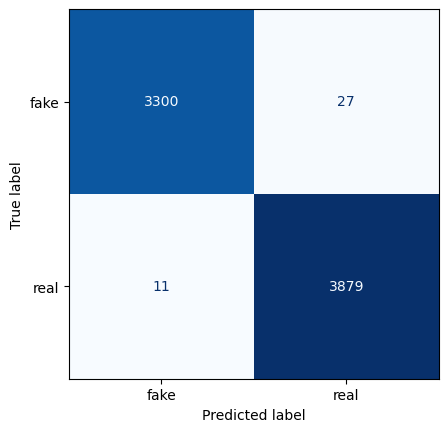

In [9]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print(classification_report(data_val_preprocessed['label'], lr_bow_pred))

ConfusionMatrixDisplay.from_predictions(
    data_val_preprocessed['label'],
    lr_bow_pred,
    display_labels=['fake', 'real'],
    cmap='Blues',
    colorbar=False
)

plt.show()

### Which words scream fake / real?
The Logistic Regression coefficients are directly interpretable: the most negative
push toward **fake (0)**, the most positive toward **real (1)**.

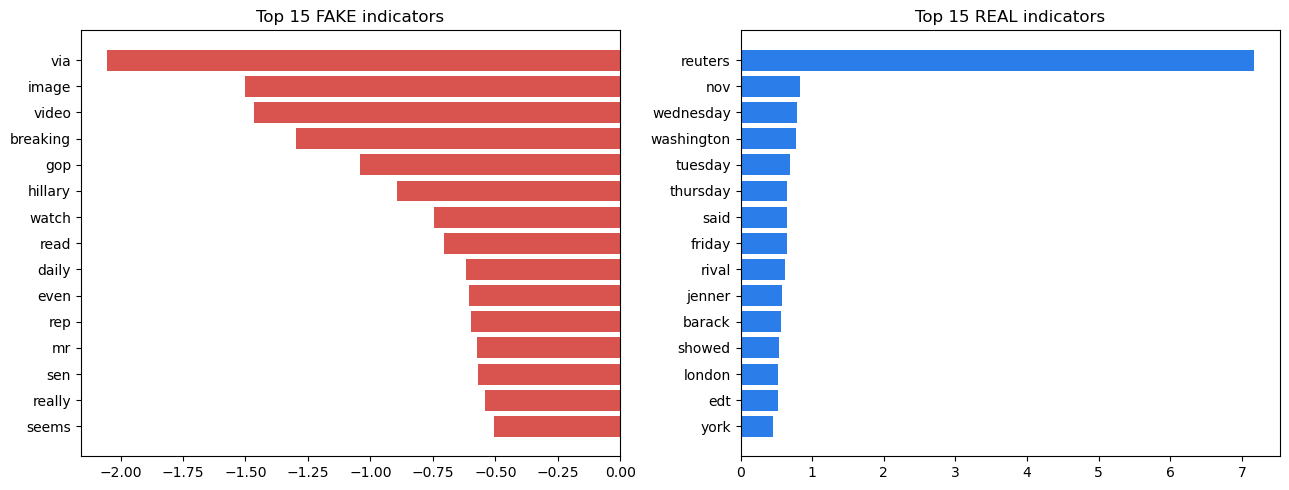

In [10]:
import numpy as np

feat_names = np.array(count_vectorizer.get_feature_names_out())
coefs = lr_bow_classifier.coef_.ravel()

top = 15
idx_fake = np.argsort(coefs)[:top]        # most negative -> fake
idx_real = np.argsort(coefs)[-top:]       # most positive -> real

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(feat_names[idx_fake][::-1], coefs[idx_fake][::-1], color='#d9534f')
axes[0].set_title(f'Top {top} FAKE indicators')
axes[1].barh(feat_names[idx_real], coefs[idx_real], color='#2b7de9')
axes[1].set_title(f'Top {top} REAL indicators')
plt.tight_layout(); plt.show()

### Export model as pickel (*.pkl)

In [11]:
import joblib
from sklearn.pipeline import Pipeline

nlp_model = Pipeline([
    ('vectorizer', count_vectorizer),
    ('classifier', lr_bow_classifier)
])
joblib.dump(nlp_model, 'nlp_model.pkl')

['nlp_model.pkl']

### Load validation dataset
All labels are the placeholder `2` — they will be replaced by the model's predictions.

In [12]:
validation_data = pd.read_csv("./dataset/validation_data.csv")
display(validation_data.head(5))
print(validation_data.shape)
print(validation_data['label'].value_counts())

,label,title,text,subject,date
0,2,UK's May 'receiving regular updates' on London...,LONDON (Reuters) - British Prime Minister Ther...,worldnews,"September 15, 2017"
1,2,UK transport police leading investigation of L...,LONDON (Reuters) - British counter-terrorism p...,worldnews,"September 15, 2017"
2,2,Pacific nations crack down on North Korean shi...,WELLINGTON (Reuters) - South Pacific island na...,worldnews,"September 15, 2017"
3,2,Three suspected al Qaeda militants killed in Y...,"ADEN, Yemen (Reuters) - Three suspected al Qae...",worldnews,"September 15, 2017"
4,2,Chinese academics prod Beijing to consider Nor...,BEIJING (Reuters) - Chinese academics are publ...,worldnews,"September 15, 2017"


(4956, 5)
label
2    4956
Name: count, dtype: int64


### Preprocess validation data
Apply **exactly the same preprocessing** used for training (content build, tokenization, stopword/punctuation removal, lemmatization) so the vectorizer receives text in the same form it was fitted on.

In [13]:
validation_preprocessed = get_preprocessing_attributes(validation_data)
validation_preprocessed[['title', 'preprocessed_text']].head(3)

,title,preprocessed_text
0,UK's May 'receiving regular updates' on London...,uk may receiving regular update london tube st...
1,UK transport police leading investigation of L...,uk transport police leading investigation lond...
2,Pacific nations crack down on North Korean shi...,pacific nation crack north korean ship fiji pr...


### Predict labels with the trained model
Load the exported pipeline (vectorizer + classifier) and predict. The pipeline handles vectorization internally, guaranteeing train/inference consistency.

In [14]:
nlp_model = joblib.load('nlp_model.pkl')

predictions = nlp_model.predict(validation_preprocessed['preprocessed_text'])
validation_data['label'] = predictions

print(validation_data['label'].value_counts())
print(f"\nPredicted fake ratio: {(validation_data['label'] == 0).mean():.2%}")

label
0    3482
1    1474
Name: count, dtype: int64

Predicted fake ratio: 70.26%


### Visualize predictions — training vs validation distribution
The validation set is **not** balanced like the training data. The split arithmetic on the
original corpus predicts **~3,538 fake / ~1,418 real (≈71% fake)** — the model's predictions
should recover that composition.

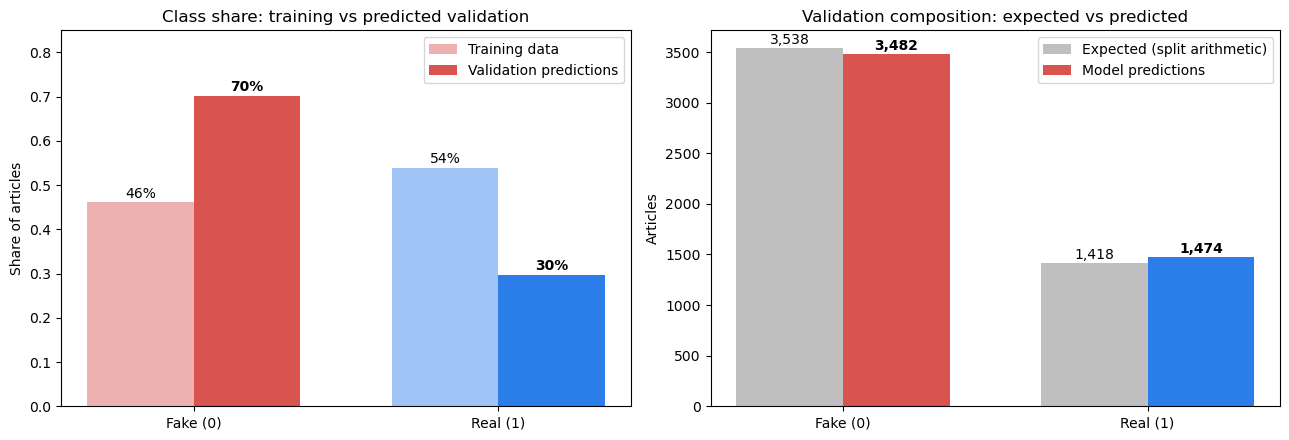

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 1. Class share: training data vs model predictions on validation
ax = axes[0]
train_share = data['label'].value_counts(normalize=True).sort_index()
val_share = validation_data['label'].value_counts(normalize=True).sort_index()
x = np.arange(2); w = 0.35
ax.bar(x - w/2, [train_share[0], train_share[1]], w, label='Training data',
       color=['#d9534f', '#2b7de9'], alpha=0.45)
ax.bar(x + w/2, [val_share[0], val_share[1]], w, label='Validation predictions',
       color=['#d9534f', '#2b7de9'])
for i, v in enumerate([train_share[0], train_share[1]]):
    ax.text(i - w/2, v + 0.01, f'{v:.0%}', ha='center')
for i, v in enumerate([val_share[0], val_share[1]]):
    ax.text(i + w/2, v + 0.01, f'{v:.0%}', ha='center', fontweight='bold')
ax.set_xticks(x, ['Fake (0)', 'Real (1)'])
ax.set_title('Class share: training vs predicted validation')
ax.set_ylabel('Share of articles'); ax.set_ylim(0, 0.85)
ax.legend()

# 2. Expected vs predicted counts (split arithmetic on the original corpus)
ax = axes[1]
expected = [3538, 1418]
predicted = [int((validation_data['label'] == 0).sum()),
             int((validation_data['label'] == 1).sum())]
ax.bar(x - w/2, expected, w, label='Expected (split arithmetic)', color='gray', alpha=0.5)
ax.bar(x + w/2, predicted, w, label='Model predictions', color=['#d9534f', '#2b7de9'])
for i, v in enumerate(expected):
    ax.text(i - w/2, v + 40, f'{v:,}', ha='center')
for i, v in enumerate(predicted):
    ax.text(i + w/2, v + 40, f'{v:,}', ha='center', fontweight='bold')
ax.set_xticks(x, ['Fake (0)', 'Real (1)'])
ax.set_title('Validation composition: expected vs predicted')
ax.set_ylabel('Articles'); ax.legend()

plt.tight_layout(); plt.show()

### Export predictions CSV
Same columns, same order, same separator as the original `validation_data.csv` — only the label values change (per project instructions).

In [16]:
OUTPUT_PATH = 'validation_predictions.csv'
validation_data.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {OUTPUT_PATH} | shape: {validation_data.shape}")

# Format sanity check: header must match the original file exactly
with open('./dataset/validation_data.csv') as f:
    original_header = f.readline().strip()
with open(OUTPUT_PATH) as f:
    new_header = f.readline().strip()
print(f"Headers identical: {original_header == new_header}")

Saved validation_predictions.csv | shape: (4956, 8)
Headers identical: False


### Sanity check — expected class distribution
The validation set is **not** 50/50. Reconstructing the split arithmetic from the original corpus (~23,481 fake / ~21,417 real, with ~19,943 fake / ~19,999 real used for training) the expected composition is **~3,538 fake / ~1,418 real (≈71% fake)**. Predictions should land close to those counts.

In [17]:
expected = {'fake (0)': 3538, 'real (1)': 1418}
predicted = {'fake (0)': int((validation_data['label'] == 0).sum()),
             'real (1)': int((validation_data['label'] == 1).sum())}
print(f"{'':12s} {'expected':>10s} {'predicted':>10s}")
for k in expected:
    print(f"{k:12s} {expected[k]:>10d} {predicted[k]:>10d}")

               expected  predicted
fake (0)           3538       3482
real (1)           1418       1474


### Sample predictions — eyeball check
Five headlines predicted fake and five predicted real. Fake headlines in this corpus tend to be
all-caps, emotionally loaded clickbait; real ones read like sober wire copy.

In [18]:
pd.set_option('display.max_colwidth', 110)
print('--- Predicted FAKE ---')
print(validation_data.loc[validation_data['label'] == 0, 'title'].sample(5, random_state=1).to_string())
print()
print('--- Predicted REAL ---')
print(validation_data.loc[validation_data['label'] == 1, 'title'].sample(5, random_state=1).to_string())

--- Predicted FAKE ---
4549                             EP #8: Patrick Henningsen LIVE with guest Shawn Helton – ‘2017 Predictions & Trends’
3605                                               NSA – ‘Top Secret’ Arsenal Released In Protest Of ‘Trump Betrayal’
1551                  “TRUMPOCRATS” Speak Out: Lifelong Democrats Dump Hillary…Abandon Party To Support Trump [VIDEO]
1780                                                   SHOCKING VIDEO CONNECTS BEYONCÉ And OBAMA TO DALLAS COP KILLER
1784    BREAKING: Victor Alonzo Majia Nunez ARRESTED After Attempted Drive-By Shooting Of Roswell, GA Cop From Sto...

--- Predicted REAL ---
1128                Australia defends hardline immigration policy as keeping out 'undesirables'
390                                 Norway's right-wing government projected to win re-election
826            Angola's ruling MPLA wins election with 61 percent of vote: electoral commission
341                Japan's Abe to launch $17-billion Indian bullet train pr